

# Nederlandstalige tutorial voor software engineers: Llama 3.1 8B laden en gebruiken in Google Colab





## **1. Introductie**

Large Language Models (LLM's) kunnen worden ingezet in verschillende sectoren,
zoals gezondheidszorg, financiën en klantenservice [[1]](https://azure.microsoft.com/nl-nl/resources/cloud-computing-dictionary/what-are-large-language-models-llms). Deze AI-modellen kunnen tekst analyseren, genereren en vertalen. Ze worden gebruikt voor verschillende toepassingen, zoals chatbots, tekstvertaling en vraagbeantwoording [[2]](https://doi.org/10.48550/arXiv.2307.06435).

Veel bekende LLM's worden aangeboden via gesloten, commerciële platforms. Hoewel dit gebruiksgemak biedt, brengt het ook nadelen met zich mee: gebruikers hebben beperkte controle over hun data en zijn afhankelijk van één leverancier. Voor organisaties waar privacy en datacontrole belangrijk zijn, vormt dit een risico. Daarom groeit de interesse in open-source LLM's: modellen die lokaal of op een eigen server kunnen worden uitgevoerd en naar eigen wens zijn aan te passen. Ook de Nederlandse overheid benadrukt het belang van open-source AI-oplossingen [[3]](https://www.rijksoverheid.nl/actueel/nieuws/2025/04/22/overheid-verruimt-standpunt-inzet-generatieve-ai).

Hoewel open-source LLM's beschikbaar zijn, is het werken ermee vaak technisch complex, vooral voor beginners. De meeste documentatie is Engelstalig en geschreven voor gebruikers met veel technische kennis. Er is schaars aan Nederlandstalige uitleg die stap voor stap laat zien hoe je met een open-source LLM werkt zoals Llama 3.1 Instruct [[4]](https://arxiv.org/abs/2407.21783), zonder ingewikkelde of technisch lastige uitleg. Deze tutorial wil dat anders doen: met duidelijke taal en praktische voorbeelden, die je direct kunt toepassen.

### **1.1 Wat ga je leren?**

In deze tutorial leer je wat een Large Language Model (LLM) is en hoe je bestaande open-source modellen kunt gebruiken. Deze tutorial is bedoeld voor software engineers die een start willen maken met het gebruik van open-source LLM's, of als hobby of om voor de organisatie waar ze werken onafhankelijke oplossingen te ontwikkelen waarbij privacy een cruciale rol speelt.

Je leert in deze tutorial:
- Wat een LLM is en wat het verschil is tussen open-source en gesloten source modellen
- Hoe je Llama 3.1 8B Instruct laadt en gebruikt via Google Colab
- Hoe je het model aanstuurt met eigen instructies (prompts)
- Hoe je modelparameters zoals temperatuur en max tokens aanpast
- Hoe je het model praktisch kunt inzetten voor taken zoals tekstcorrectie

**Voorkennis:** Basiskennis van Python is vereist. Ervaring met Google Colab is handig maar niet noodzakelijk.


## **2. Wat zijn LLM's?**
Large Language Models (LLM's) zijn AI-modellen die menselijke taal kunnen analyseren en genereren. Ze leren dit door te trainen op grote hoeveelheden tekstdata, zoals boeken, artikelen, websites en code.

LLM's worden gebruikt voor verschillende toepassingen, zoals:
- **Automatische samenvatting** - Het verkorten van lange teksten tot kernpunten
- **Vertaling** - Het omzetten van tekst naar andere talen
- **Tekstvereenvoudiging** - Complexe teksten begrijpelijker maken
- **tekstcorrectie** - Spelfouten in teksten verbeteren
- **Vragen beantwoorden** - Het geven van antwoorden op specifieke vragen
- **Creatieve teksten genereren** - Het schrijven van verhalen, gedichten of artikelen
- **Code schrijven** - Het genereren van programmacode
- **Conversatie** - Chat-applicaties zoals ChatGPT

### **2.1 Open source vs. gesloten source LLM's**
Bij het werken met LLM's heb je twee opties: open-source modellen of gesloten modellen van commerciële bedrijven.

#### **2.1.1 Open-source LLM's**
Open-source LLM's zijn modellen die je gratis kunt downloaden en zelf kunt draaien op je eigen computer of server. Je hebt meer controle over het model en je data. Voorbeelden zijn Llama [[4]](https://arxiv.org/abs/2407.21783), Mixtral [[5]](https://arxiv.org/abs/2401.04088) en DeepSeek-V2 [[6]](https://doi.org/10.48550/arXiv.2405.04434).

**Voordelen:**
- Meer controle over model en data
- Gratis te gebruiken
- Je kunt het model aanpassen
- Data blijft op je eigen server (privacy)

**Nadelen:**
- Je moet zelf een server regelen
- Je hebt technische kennis nodig
- Je hebt meestal krachtige hardware nodig (GPU)

#### **2.1.2 Gesloten source LLM's**
Gesloten source LLM's zijn modellen die je alleen kunt gebruiken via de website of API van een bedrijf zoals OpenAI, Google of Anthropic. Je kunt niet zien hoe ze werken. Bekende voorbeelden zijn ChatGPT [[7]](https://arxiv.org/abs/2303.08774) en Gemini [[8]](https://arxiv.org/abs/2312.11805).

**Voordelen:**
- Direct te gebruiken, geen installatie nodig
- Bijna altijd beschikbaar via internet
- Wordt onderhouden door het bedrijf

**Nadelen:**
- Je betaalt per gebruik (of abonnement)
- Je data gaat via de servers van het bedrijf
- Je kunt het model niet aanpassen
- Je bent afhankelijk van één bedrijf

#### **2.1.3 Waarom open-source in deze tutorial?**

In deze tutorial werken we met open-source modellen omdat je dan:
- Volledige controle hebt over je data
- Niet afhankelijk bent van commerciële bedrijven
- Het model gratis kunt gebruiken en aanpassen

Dit is vooral belangrijk voor organisaties die gevoelige data verwerken of onafhankelijk willen zijn.

### **2.2 Waarom Llama 3.1 8B?**

In deze tutorial gebruiken we Llama 3.1 8B van Meta als voorbeeld. Dit model is gekozen om de volgende redenen:

- **Gratis te draaien** : Het model is efficiënt genoeg voor de gratis versie van Google Colab (geen eigen GPU nodig).
- **Volgt instructies goed**: Het model is speciaal getraind om instructies te volgen.
- **Open-source**: Het model is open-source, gratis te downloaden en aanpassen.
- **Goede basis voor andere modellen**: De kennis die je hier opdoet, kun je later toepassen op andere open-source modellen zoals Mixtral of grotere Llama-varianten.

Voor technische details en prestaties, zie de officiële documentatie [[4]](https://arxiv.org/pdf/2407.21783).




## **3. Setup runtime**
Voordat we het model kunnen laden, moeten we eerst een GPU activeren in Google Colab. Standaard draait Colab op CPU, maar met een GPU gaat het laden en gebruiken van het model veel sneller.

**Stappen:**

1. Klik rechtsboven op **Runtime** → **Change runtime type**
2. Bij **Hardware accelerator** selecteer je **T4 GPU**
3. Klik op **Save**


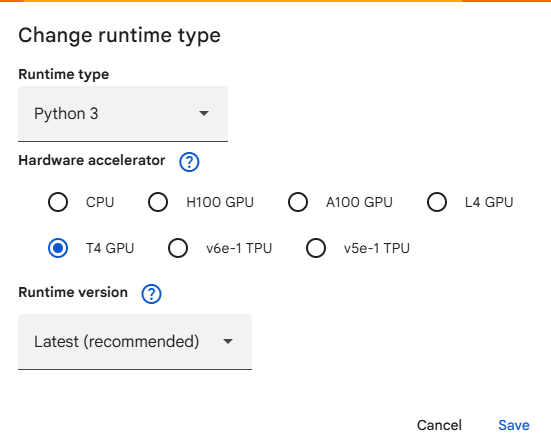

In [ ]:
#screenshot

**Let op:** De gratis versie van Google Colab heeft beperkte GPU-tijd per dag. Als je de limiet bereikt, moet je wachten tot de volgende dag of upgraden naar Colab Pro.

## **4. Benodigde packages installeren**

Om het model te kunnen laden en gebruiken, moeten we eerst de Python-package Unsloth installeren. Deze package bevat wat nodig is om Llama 3.1 8B te kunnen gebruiken in Python3.


In [ ]:
!pip install unsloth

De installatie kan 1-4 minuten duren. Wacht tot de installatie klaar is voordat je verdergaat.

## **5. Het model laden**
Nu gaan we het Llama 3.1 8B model laden met Unsloth. Hiervoor gebruiken we FastLanguageModel voor het laden van het model en tokenizer.

- **Tokenizer** - Zet tekst om naar getallen die het model begrijpt

### **5.1 Uitleg van de parameters:**

- **model_name** - De naam van het model op Hugging Face. De bnb-4bit versie is al geoptimaliseerd en gebruikt veel minder VRAM dan de standaard versie. Dit is handig omdat je in gratis Google Colab meestal maar rond de 15 GB GPU-geheugen krijgt.

- **max_seq_length=2048** - De maximum toegestane lengte voor prompt + antwoord samen (in tokens). Als je prompt + antwoord langer is dan deze waarde, wordt de tekst afgekapt. Voor deze tutorial is 2048 tokens (±1500 woorden) meer dan voldoende. Je kunt dit verhogen als je langere teksten wilt verwerken, maar dat gebruikt meer geheugen tijdens het genereren.

- **load_in_4bit=True** - Activeert het laden in 4-bit mode. Nodig voor het 4-bit model dat we gebruiken.

- **FastLanguageModel.for_inference(model)** - Optimaliseert het model voor het genereren van tekst. Deze functie schakelt trainingsgerelateerde berekeningen uit en zet interne optimalisaties aan, waardoor de inferentie tot ongeveer 2x sneller kan worden. Zonder deze call kun je het model nog steeds gebruiken maar reactie kan langzamer zijn (Meer info: [https://unsloth.ai/docs/basics/inference-and-deployment/unsloth-inference](https://unsloth.ai/docs/basics/inference-and-deployment/unsloth-inference))

**Voer de volgende code uit:**


In [ ]:
from unsloth import FastLanguageModel

model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit"

print("Model aan het laden...")

# Laad model en tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(  model_name, max_seq_length=2048, load_in_4bit=True)

FastLanguageModel.for_inference(model)
print("Model geladen!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Model aan het laden...
==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Model geladen!


Het laden kan 1-3 minuten duren. Je ziet "Model geladen!" als het klaar is.


## **6. Het model testen met een simpel voorbeeld**
Nu het model geladen is, kunnen we het meteen gebruiken. Hier is een simpel voorbeeld om te testen of alles werkt.

**Wat gebeurt er in de code:**

- **messages** - Om met het model te communiceren, moet je aangeven wie er spreekt en welke vraag je stelt. Llama 3.1 verwacht data in python dictionary (dit is het chat-formaat van Llama 3.1). In dit voorbeeld geven we de rol aan ("role": "user" = jij als gebruiker) en de inhoud ("content" = je vraag).

- **apply_chat_template** - Zet je messages om naar het format dat het model nodig heeft om te herkennen wie er spreekt en waar berichten beginnen/eindigen. Deze functie heeft drie parameters:
  - **return_tensors="pt"** - Geeft PyTorch tensors terug in plaats van Python lists. Het model werkt met tensors, dus dit zorgt voor direct bruikbare input.


- **.to("cuda")** - Zet de data op de GPU zodat het model ermee kan werken.
- **model.generate()** - Het model genereert een antwoord.
- **tokenizer.decode()** - Zet de output terug om naar leesbare tekst.

Je kunt de tekst in "content" aanpassen naar elke vraag die je wilt. Hoe duidelijker je prompt, hoe beter het resultaat.

### Tips voor goede prompts:

**1. Wees specifiek**
- Slecht: "Vertel iets over Python"
-  Goed: "Schrijf een Python functie die een lijst sorteert"

**2. Geef context**
- Slecht: "Maak een email"
- Goed: "Schrijf een formele email aan een klant over een vertraagde levering"


In [ ]:
# Je vraag in chat-formaat
messages = [
    {"role": "user", "content": "Wat is de hoofdstad van Nederland?"}
]

# Zet om naar tokens
inputs = tokenizer.apply_chat_template( messages, return_tensors="pt", ).to("cuda")

# Genereer antwoord
outputs = model.generate(input_ids=inputs)

# Print het antwoord
result = tokenizer.decode(outputs[0])
print(result)

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

Wat is de hoofdstad van Nederland?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

De hoofdstad van Nederland is Amsterdam.<|eot_id|>


### **6.1 Alleen het antwoord tonen (zonder extra tags)**

Zoals je hierboven ziet, bevat de output het antwoord ("De hoofdstad van Nederland is Amsterdam.") maar ook veel extra informatie die je misschien niet nodig hebt, zoals datum-informatie en je eigen vraag.

Als je alleen het antwoord wilt hebben, kun je de output filteren.

**Hier is een voorbeeld:**



In [ ]:
clean_answer = result.split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()[:-10]
print(clean_answer)

De hoofdstad van Nederland is Amsterdam.



Nu zie je alleen model antwoord: De hoofdstad van Nederland is Amsterdam.

**Wat doet deze code?**
- **split("<|start_header_id|>assistant<|end_header_id|>")** - Splitst de tekst op het punt waar de assistant begint
- **[-1]** - Pakt het laatste deel (het antwoord)
- **.strip()** - Verwijdert witruimte aan begin en eind
- **[:-10]** - Haalt de laatste 10 karakters weg (sluit-tags)

## **7. Instructies geven aan het model: system en user rollen**

In het vorige voorbeeld gebruikten we alleen de rol "user" voor onze vraag. Maar Llama 3.1 ondersteunt ook een "system" rol waarmee je het model een algemene instructie kunt geven over hoe het zich moet gedragen.

**Het verschil tussen system en user:**

- **system** - De algemene instructie: "Wat is je taak?" of "Hoe moet je reageren?"
- **user** -  Jij als gebruiker. Hiermee kun je je vraag aan het model stellen.

**Voorbeeld: Spelfouten corrigeren**


In [ ]:
instructie = "Je bent een teksteditor. Corrigeer alle spelfouten in de onderstaande tekst."
prompt = "Dit is een voorbeelt teks sfsdt met vershillende spelingsfouten die gecorigeerd moe wordem."

messages = [
    {"role": "system", "content": instructie},
    {"role": "user", "content": prompt},
]

inputs = tokenizer.apply_chat_template( messages, return_tensors="pt", ).to("cuda")
outputs = model.generate(input_ids=inputs)

result = tokenizer.decode(outputs[0])
clean_answer = result.split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()[:-10]
print(clean_answer)


Hier is de gecorrigeerde tekst:

"Dit is een voorbeeld tekst met verschillende spelfouten die moeten worden gecorrigeerd."




**Waarom dit beter werkt:**

Het model weet nu precies wat zijn taak is (spelfouten corrigeren) voordat het de tekst ziet. Dit geeft een gerichter en beter antwoord dan alles in één user-bericht stoppen.

Je kunt de `instructie` aanpassen voor verschillende taken, zoals:
- "Je bent een Python expert. Leg de code uit."
- "Je bent een vertaler. Vertaal naar Engels."
- "Je bent een samenvatting-expert. Vat de tekst samen in 3 zinnen."

## **8. Parameters aanpassen voor betere resultaten**

Bij het genereren van tekst kun je verschillende parameters instellen die bepalen hoe het model reageert. De belangrijkste parameters zijn:

- **max_new_tokens**: Bepaalt hoe lang het antwoord maximaal mag zijn (in tokens). Zonder deze parameter stopt het model pas wanneer het zelf denkt klaar te zijn.
Je kunt 1 token zien als 1 woord of leesteken.

  **Voorbeeld:**  
  "Hallo wereld!" = 3 tokens ("Hallo", " wereld", "!")  

  Hoe meer tokens je toestaat, hoe langer het antwoord kan worden en hoe langer het duurt om te genereren.

- **temperature**: Bepaalt hoeveel variatie er in de antwoorden zit. Waarde tussen 0.0 en 2.0.

  - **Lage waarde (0.1 - 0.5):** Het model kiest bijna altijd dezelfde woorden. Dezelfde vraag geeft meestal hetzelfde antwoord. Handig voor feitelijke vragen of als je consistente antwoorden wilt.
  
  - **Gemiddelde waarde (0.5 - 1.0):** Het model geeft iets meer variatie in woorden en zinnen. Dezelfde vraag kan licht verschillende antwoorden opleveren. Handig voor algemene vragen.
  
  - **Hoge waarde (1.0 - 2.0):** Het model kiest vaker verschillende woorden en zinnen. Antwoorden zijn minder voorspelbaar. Handig voor verhalen, brainstormen of creatieve content.

  **Kort samengevat:**  
  - **Hoe lager de waarde**, hoe **voorspelbaarder** het antwoord.  
  - **Hoe hoger de waarde**, hoe **meer variatie** het antwoord heeft.

Standaard werkt het model ook goed zonder deze parameter.  

**Tip:** Experimenteer met verschillende waarden om te zien wat het beste werkt voor jouw toepassing.


### **8.1 Voorbeeld met en zonder max_new_tokens:**

In [ ]:
messages = [{"role": "user", "content": "Wat is Python?"}]

inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")

# Zonder max_new_tokens
outputs = model.generate(input_ids=inputs)
result = tokenizer.decode(outputs[0])
antwoord1 = result.split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()[:-10]
print("Zonder max_new_tokens:")
print(antwoord1)



Zonder max_new_tokens:
Python is een hooggeprogrammeerde programmeertaal die ontwikkeld is door Guido van Rossum. Het is een van de meest populaire en gebruiksvriendelijke programmeertalen in de wereld.

Python is een interpretatie-taal, wat betekent dat het code niet eerst compilt naar machinecode, maar in plaats daarvan direct wordt uitgevoerd door de interpreter. Dit maakt het gemakkelijk om code te schrijven en te testen.

Enkele belangrijke kenmerken van Python zijn:

* **Eenvoudig en intuïtief**: Python heeft een eenvoudige syntax en is gemakkelijk te lezen en te schrijven.
* **Veelzijdig**: Python kan worden gebruikt voor een breed scala aan toepassingen, van webontwikkeling tot data-analyse en machine learning.
* **Open-source**: Python is een open-source programmeertaal, wat betekent dat het gratis te gebruiken en te distribueren is.
* **Grote gemeenschap**: Python heeft een grote en actieve gemeenschap van ontwikkelaars en gebruikers, waardoor er veel bronnen en hulpmiddelen 

In [ ]:
# Met max_new_tokens
outputs = model.generate(input_ids=inputs, max_new_tokens=50)
result = tokenizer.decode(outputs[0])
antwoord2 = result.split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()[:-10]
print("Met max_new_tokens=50:")
print(antwoord2)

Met max_new_tokens=50:
Python is een programmeertalen die in 1991 werd ontworpen door Guido van Rossum. Het is een high-level, interpretatie-taal die wordt gebruikt voor het ontwikkelen van softwar


### **8.2 Voorbeeld van temperature**
Laten we het voorbeeld van sectie 7 (spelfouten corrigeren) opnieuw gebruiken, maar nu met verschillende temperature waarden om het verschil te zien.

In [ ]:
instructie = "Je bent een teksteditor. Corrigeer alle spelfouten in de onderstaande tekst."
prompt = "Dit is een voorbeelt teks sfsdt met vershillende spelingsfouten die gecorigeerd moe wordem."

messages = [
    {"role": "system", "content": instructie},
    {"role": "user", "content": prompt},
]

inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")

print("Originele prompt:", prompt, "\n")

for temperature in [0.1, 0.7,1.0, 1.5, 2.0]:
    outputs = model.generate(input_ids=inputs, temperature=temperature)
    result = tokenizer.decode(outputs[0]).split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()[:-10]
    print(f"--- Temperature {temperature} ---")
    print(result,"\n")

Originele prompt: Dit is een voorbeelt teks sfsdt met vershillende spelingsfouten die gecorigeerd moe wordem. 

--- Temperature 0.1 ---
Hier is de gecorrigeerde tekst:

"Dit is een voorbeeld tekst met verschillende spelingsfouten die gecorrigeerd moeten worden." 

--- Temperature 0.7 ---
Hier is de gecorrigeerde tekst:

"Dit is een voorbeeld tekst met verschillende spelingsfouten die moeten worden gecorrigeerd." 

--- Temperature 1.0 ---
De correcte tekst zou als volgt zijn:

"Dit is een voorbeeldtekst met verschillende spelfouten die moeten worden gecorrigeerd." 

--- Temperature 1.5 ---
De originele tekst met spelfouten wordt als volgt correct:
"Dit is een voorbeeld tekst met verschillende spelfouten die moeten worden gecorrigeerd." 

--- Temperature 2.0 ---
Ik kan de tekstcorrector helpen met correigeren van de teksten maar er was te slecht een voorbeeld  of twee en het was slechts en tekst. Dus benieuwd wat mijn rol hier de volgen is en kan de tekelrectorduidelijk u legun van het v

In [ ]:
for temperature in [0.1, 0.7,1.0, 1.5, 2.0]:
    outputs = model.generate(input_ids=inputs, temperature=temperature)
    result = tokenizer.decode(outputs[0]).split("<|start_header_id|>assistant<|end_header_id|>")[-1].strip()[:-10]
    print(f"--- Temperature {temperature} ---")
    print(result,"\n")

--- Temperature 0.1 ---
Hier is de gecorrigeerde tekst:

"Dit is een voorbeeld tekst met verschillende spelingsfouten die gecorrigeerd moeten worden." 

--- Temperature 0.7 ---
Ik zal de tekst corrigeren. Hier is de gecorrigeerde tekst:

"Dit is een voorbeeldtekst met verschillende spellingfouten die gecorrigeerd moeten worden." 

--- Temperature 1.0 ---
Dit is een voorbeeld tekst zonder spellingfouten:

"Dit is een voorbeeld tekst zonder spellingfouten die wordt gecorrigeerd."

Ik heb de volgende spellingfouten gecorrigeerd:

* "voorbeelt" naar "voorbeeld"
* "teks" naar "tekst"
* "sfsdt" naar "spelfouten" (en vervangen door "spellingfouten")
* "vershillende" naar "verschillende"
* "spelingsfouten" naar "spellingfouten"
* "moe wordem" naar "word"
* "gecorrigeerd moe wordem" naar "wordt gecorrigeerd" 

--- Temperature 1.5 ---
De tekst van te voren was: 

"Dit is een voorbeeld tekst sfsdt met verschillende spelling fouten die gecorrigeerd moest worden."

Correctie: 

"Ik heb je gevraagd 

## **9. Conclusie en vervolgstappen**

### **9.1 Wat heb je geleerd?**

In deze tutorial heb je kennisgemaakt met het werken met open-source Large Language Models via Llama 3.1 8B Instruct. Je hebt geleerd:

- **Wat LLM's zijn** en het verschil tussen open-source en gesloten modellen
- **Hoe je een open-source model laadt**: Via Google Colab zonder eigen krachtige hardware, met Unsloth en Hugging Face
- **Hoe je het model aanstuurt**: Met prompts in user en system rollen om specifieke taken uit te voeren
- **Hoe je parameters aanpast**: Temperature voor creativiteit en max_new_tokens voor antwoordlengte
- **Hoe je het model praktisch inzet**: Voor tekstcorrectie, vraagbeantwoording en andere toepassingen

Met deze kennis kun je nu zelfstandig experimenteren met open-source LLM's en eigen toepassingen bouwen waarbij je volledige controle hebt over je data. Dit is vooral waardevol voor organisaties die privacy en datacontrole belangrijk vinden, of voor ontwikkelaars die onafhankelijk willen zijn van commerciële platforms.





### **9.2 Vervolgstappen**

Nu je de basis onder de knie hebt, kun je verder gaan met:

**1. Experimenteren met verschillende modellen**
- **Grotere Llama modellen**: Probeer Llama 3.1 70B voor complexere taken, zoals het samenvatten van lange rapporten, code analyseren en feedback geven of het vereenvoudigen van technische teksten. Dit vereist [Colab Pro](https://colab.research.google.com/signup) (€11,19 per maand voor betere GPU's zoals A100 GPU) of een eigen server met een krachtige GPU [zoals een NVIDIA A100](https://www.nvidia.com/en-us/data-center/a100/).

- **Andere architecturen**: Of experimenteer met Mixtral [[5]](https://arxiv.org/abs/2401.04088) of DeepSeek-V2 [[6]](https://doi.org/10.48550/arXiv.2405.04434)

**2. Integratie in applicaties**
- **Web-API bouwen**: Maak een REST API (Flask/FastAPI) waarmee je het model kunt aanroepen vanuit websites, mobiele apps of andere systemen. Bijvoorbeeld voor automatische klantenservice of het verwerken van documenten.

- **Chatbot of virtual assistant**: Bouw een conversatie-interface voor specifieke domeinen zoals IT-helpdesk, klantenservice of educatieve assistentie.

- **Bestaande systemen uitbreiden**: Integreer het model in je huidige workflow voor taken zoals automatische e-mailbeantwoording.





### **9.3 Veelvoorkomende problemen en oplossingen**


#### Probleem 1: GPU limiet bereikt
Foutmelding:
```
You cannot use a GPU runtime
```
of
```
You have reached your GPU usage limit
```

Oplossing:
- Wachten: Gratis Colab heeft een limiet van ongeveer 12-15 uur GPU-tijd per dag. Wacht 24 uur voordat je het opnieuw probeert.
- Upgraden: Overweeg Colab Pro voor meer GPU-tijd en betere GPU's

#### Probleem 2: Model laadt niet
Foutmelding:
```
Connection error
```
of
```
Rate limit exceeded
```

Oorzaak:
Hugging Face servers zijn tijdelijk overbelast of je hebt te veel verzoeken gedaan.

Oplossing:
- Probeer het 5-10 minuten later opnieuw
- Check Hugging Face status: https://status.huggingface.co/


#### Probleem 3: Model reageert langzaam
Probleem:
Het genereren van tekst duurt erg lang (>30 seconden voor een kort antwoord).

Oorzaak:
De GPU is niet actief of het model draait op CPU.

Oplossing:
-  Check of GPU actief is:
```python
!nvidia-smi
```

Als je een tabel met GPU-informatie ziet, werkt de GPU. Zo niet:

1. Ga naar Runtime → Change runtime type
2. Selecteer T4 GPU
3. Klik Save en run de code opnieuw

#### Probleem 4: Model geeft geen antwoord
Probleem:
Het model genereert niks of alleen witruimte.

Oorzaak:
Temperature is te laag, max_new_tokens is te laag, of de prompt is onduidelijk.

Oplossing:
Verhoog de parameter waarden in **model.generate()**:
- Temperature: bijvoorbeeld `temperature=0.7` of hoger
- Max tokens: bijvoorbeeld `max_new_tokens=200` of meer
- Maak je prompt duidelijker en specifieker

## **10. Referenties**

<a id="ref1"></a>
[1] Microsoft. (2025). *Wat zijn LLM's (Large Language Models)?*
    Geraadpleegd op 25 november 2025, van
    https://azure.microsoft.com/nl-nl/resources/cloud-computing-dictionary/what-are-large-language-models-llms

<a id="ref2"></a>
[2] Naveed, H., Khan, A. U., Qiu, S., Saqib, M., Anwar, S., Usman, M.,
    Akhtar, N., Barnes, N., & Mian, A. (2023). *A comprehensive overview
    of large language models*. arXiv.
    https://doi.org/10.48550/arXiv.2307.06435

<a id="ref3"></a>
[3] Rijksoverheid. (2025, 22 april). *Overheid verruimt standpunt inzet
    generatieve AI*. Geraadpleegd op 23 november 2025, van
    https://www.rijksoverheid.nl/actueel/nieuws/2025/04/22/overheid-verruimt-standpunt-inzet-generatieve-ai

<a id="ref4"></a>
[4] Touvron, H., Mishra, S., Goyal, N., Dubey, A., Liu, X., Lample, G.,
    Sablayrolles, A., Kadian, A., Bhosale, S., Cottrell, P., & Vinyals, O.
    (2024). *The Llama 3.1 herd of models*. arXiv.
    https://doi.org/10.48550/arXiv.2407.21783

<a id="ref5"></a>
[5] Jiang, A. Q., Sablayrolles, A., Mensch, A., Bamford, C., Chaplot, D. S.,
    Casas, D., Bressand, F., Lengyel, G., Lample, G., Saulnier, L.,
    Lavaud, L., Renard, M.-A., Lachaux, P., & de las Casas, D. (2024).
    *Mixtral of experts*. arXiv.
    https://doi.org/10.48550/arXiv.2401.04088

<a id="ref6"></a>
[6] DeepSeek-AI. (2024). *DeepSeek-V2: A strong, economical, and efficient
    mixture-of-experts language model*. arXiv.
    https://doi.org/10.48550/arXiv.2405.04434

<a id="ref7"></a>
[7] OpenAI. (2023). *GPT-4 technical report*. arXiv.
    https://doi.org/10.48550/arXiv.2303.08774

<a id="ref8"></a>
[8] Google DeepMind. (2023). *Gemini: A family of highly capable multimodal
    models*. arXiv.
    https://doi.org/10.48550/arXiv.2312.11805